## Approve or reject

One of the most common uses of interrupts is to pause before a critical action and ask for approval. For example, you might want to ask a human to approve an API call, a database change, or any other important decision.

/home/labuser/.local/lib/python3.10/site-packages/langgraph/cache/base/__init__.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


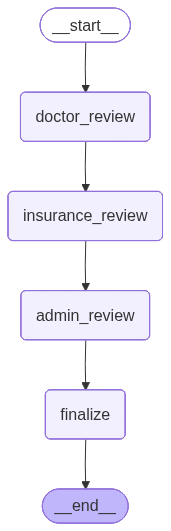

In [1]:
from typing import TypedDict, Annotated, Optional
from langgraph.graph import StateGraph, START, END
from langgraph.types import Command, interrupt
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import MemorySaver

# ---------------------
# Define State Schema
# ---------------------
class HealthcareState(TypedDict):
    case_details: str
    doctor_decision: Optional[bool] #Optional- This refers to parameters in a function definition that can be omitted when calling the function. 
    insurance_approval: Optional[bool] 
    admin_confirmation: Optional[bool]
    result: Annotated[list[str], add_messages]

# ---------------------
# Define Graph Nodes
# ---------------------
def doctor_review(state: HealthcareState):
    print(" Doctor reviewing case...")
    return {"result": ["Doctor recommends surgery"], "doctor_decision": True}

def insurance_review(state: HealthcareState):
    print(" Insurance approval pending...")
    return interrupt("Awaiting insurance company approval...")

def admin_review(state: HealthcareState):
    print(" Hospital admin review pending...")
    return interrupt("Awaiting hospital admin confirmation...")

def finalize(state: HealthcareState):
    if state.get("insurance_approval") and state.get("admin_confirmation"):
        msg = " Surgery authorized and scheduled!"
    else:
        msg = " Surgery request denied or incomplete approvals."
    print(msg)
    return {"result": [msg]}

# ---------------------
# Build Graph
# ---------------------
graph = StateGraph(HealthcareState)
graph.add_node("doctor_review", doctor_review)
graph.add_node("insurance_review", insurance_review)
graph.add_node("admin_review", admin_review)
graph.add_node("finalize", finalize)

graph.add_edge(START, "doctor_review")
graph.add_edge("doctor_review", "insurance_review")
graph.add_edge("insurance_review", "admin_review")
graph.add_edge("admin_review", "finalize")
graph.add_edge("finalize", END)

memory = MemorySaver()
compiled_graph = graph.compile(checkpointer=memory)

graph.compile(checkpointer=memory)

In [2]:
# ---------------------
# Simulate Execution
# ---------------------
config = {"configurable": {"thread_id": "case_001"}}

# Step 1 - Start case
initial = compiled_graph.invoke({"case_details": "Patient requires knee surgery"}, config=config)
print("\n--- INTERRUPT 1 ---")
print(initial["__interrupt__"])

 Doctor reviewing case...
 Insurance approval pending...

--- INTERRUPT 1 ---
[Interrupt(value='Awaiting insurance company approval...', id='77ddf4f7a9a766c60cf3375f2ec334c6')]


In [3]:
# Resume with insurance approval granted
res1 = compiled_graph.invoke(Command(resume={"insurance_approval": False}), config=config)
print("\n--- INTERRUPT 2 ---")
print(res1["__interrupt__"])


 Insurance approval pending...
 Hospital admin review pending...

--- INTERRUPT 2 ---
[Interrupt(value='Awaiting hospital admin confirmation...', id='de71fd1d8bb450e888fe13d1116df368')]


In [4]:
# Resume with admin approval granted
res2 = compiled_graph.invoke(Command(resume={"admin_confirmation": True}), config=config)
print("\n--- FINAL OUTPUT ---")
print(res2["result"])

 Hospital admin review pending...
 Surgery request denied or incomplete approvals.

--- FINAL OUTPUT ---
[HumanMessage(content='Doctor recommends surgery', additional_kwargs={}, response_metadata={}, id='ee142e49-f74b-4aac-b47d-bf3f11f774cf'), HumanMessage(content=' Surgery request denied or incomplete approvals.', additional_kwargs={}, response_metadata={}, id='d9915bae-bb49-415b-b1f0-aaf4d511af28')]
